In [1]:
import sys
sys.path.append('../src')

In [2]:
import numpy as np
from PIL import ImageFont
from palette.symbol2value import make_symbol2value_map, PALETTES
from matplotlib import pyplot as plt
from statistics import mean

In [3]:
FONT = ImageFont.truetype("../fonts/FiraCode-Regular.ttf", 11)
SYMBOLS = PALETTES['asciis']

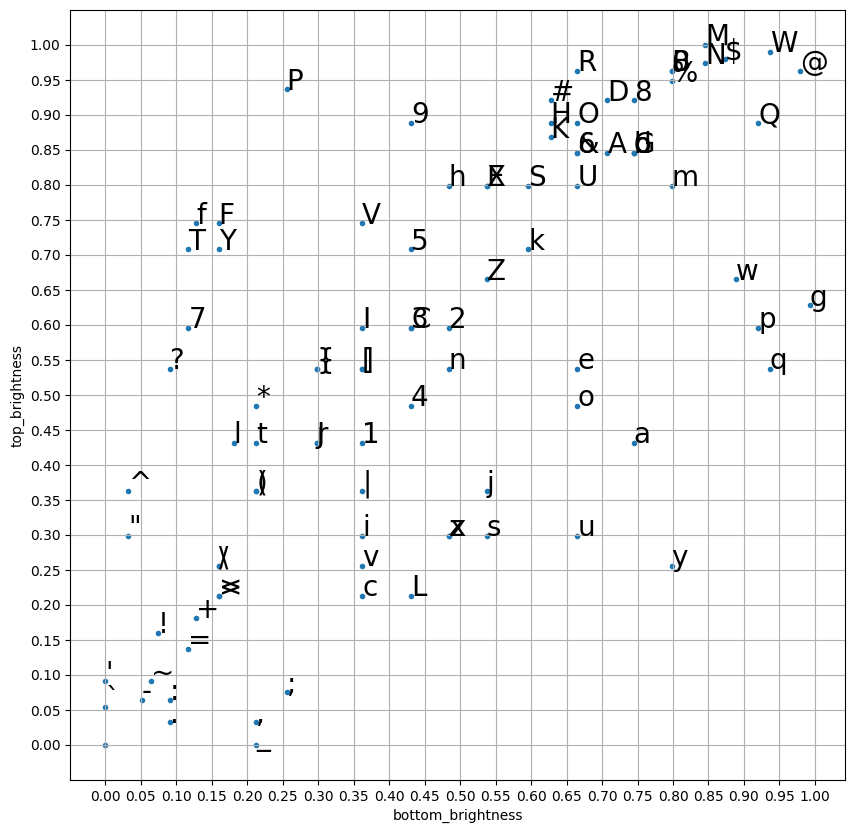

In [4]:
symbol2brightness = make_symbol2value_map(
    symbols=SYMBOLS,
    font=FONT,
    val_height=2,
    val_width=1,
    normalize=True)

brightness = list(symbol2brightness.values())
top_brightness = [b[0][0] for b in brightness]
bottom_brightness = [b[1][0] for b in brightness]

plt.figure(figsize=(10, 10))
plt.scatter(bottom_brightness, top_brightness, marker='.')
plt.xticks(np.arange(0.0, max(bottom_brightness) + 0.05, 0.05))
plt.yticks(np.arange(0.0, max(top_brightness) + 0.05, 0.05))
plt.xlabel("bottom_brightness")
plt.ylabel("top_brightness")
for s, btm_br, top_br in zip(SYMBOLS, bottom_brightness, top_brightness):
    plt.annotate(s, (btm_br, top_br), size=20)
plt.grid()

In [5]:
from converters.tile.bin_2d import make_2d_bin_palette
bins, mean_bin_brs = make_2d_bin_palette(SYMBOLS, FONT, (15, 15), normalize=True)
for row in bins:
    print(row)

[["'", '-', '`', ' '], ['.', ':'], [','], [','], [';', '_'], [';'], [';'], [';'], [';'], [';'], [';'], [';'], [';'], [';'], [';']]
[['~'], [':'], [','], [','], [';'], [';'], [';'], [';'], [';'], [';'], [';'], [';'], [';'], [';'], [';']]
[['~'], ['!', '+', '='], ['<', '>'], ['<'], ['c'], ['c'], ['c'], ['L'], ['L'], ['L'], ['L'], ['L'], ['L'], ['L'], ['L']]
[['~'], ['!'], ['<'], ['<'], ['c'], ['c'], ['c'], ['L'], ['L'], ['L'], ['L'], ['L'], ['L'], ['L'], ['L']]
[['"', '^'], ['"'], [')', '/', '\\'], [')'], ['i', 'v', '('], ['i'], ['i'], ['j', 's', 'x', 'z', '|'], ['j'], ['u'], ['u'], ['y'], ['y'], ['y'], ['y']]
[['"'], ['"'], [')'], [')'], ['i'], ['i'], ['i'], ['j'], ['j'], ['u'], ['u'], ['y'], ['y'], ['y'], ['y']]
[['"'], ['"'], [')'], [')'], ['i'], ['i'], ['i'], ['j'], ['j'], ['u'], ['u'], ['y'], ['y'], ['y'], ['y']]
[['"'], ['7', '?'], ['l', '*'], ['l'], ['1', 'r', 't', 'J', '[', '{', '}'], ['1'], ['1'], ['2', '4', 'n', ']'], ['2'], ['e', 'o'], ['e'], ['a'], ['a'], ['a'], ['p', 'q']]
[

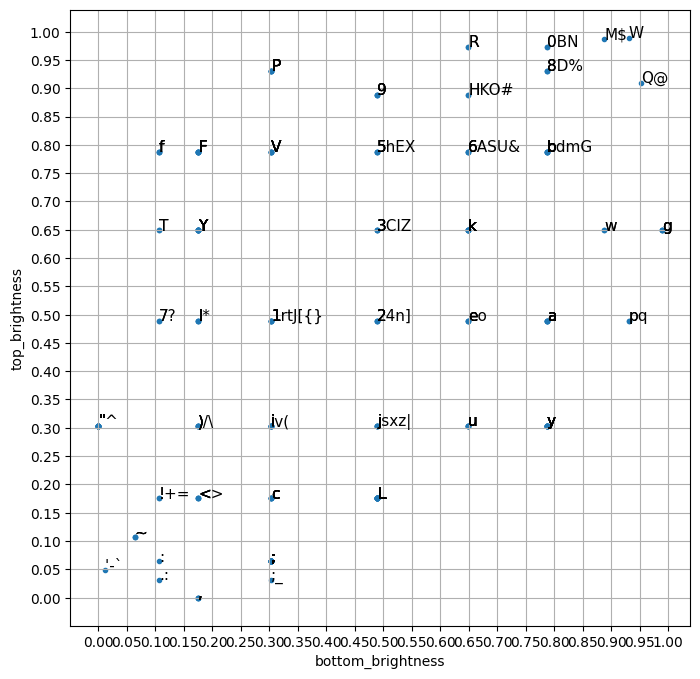

In [6]:
flat_bins = []
flat_mean_bins = []
for row in range(len(bins)):
    for col in range(len(bins[row])):
        flat_bins.append(''.join(bins[row][col]))
        flat_mean_bins.append(mean_bin_brs[row][col])

top_brightness = [b[0][0] for b in flat_mean_bins]
bottom_brightness = [b[1][0] for b in flat_mean_bins]
plt.figure(figsize=(8, 8))
plt.scatter(bottom_brightness, top_brightness, marker='.')
plt.xticks(np.arange(0.0, max(bottom_brightness) + 0.05, 0.05))
plt.yticks(np.arange(0.0, max(top_brightness) + 0.05, 0.05))
plt.xlabel("bottom_brightness")
plt.ylabel("top_brightness")
for s, btm_br, top_br in zip(flat_bins, bottom_brightness, top_brightness):
    plt.annotate(s, (btm_br, top_br), size=11)
plt.grid()

In [7]:
palette = []
for row in bins:
    palette.append([])
    for bin in row:
        sorted_bin = sorted(bin, key=lambda s: np.mean(symbol2brightness[s]))
        c = sorted_bin[len(sorted_bin)//2]
        palette[-1].append(c)
    print(palette[-1])

["'", ':', ',', ',', ';', ';', ';', ';', ';', ';', ';', ';', ';', ';', ';']
['~', ':', ',', ',', ';', ';', ';', ';', ';', ';', ';', ';', ';', ';', ';']
['~', '=', '>', '<', 'c', 'c', 'c', 'L', 'L', 'L', 'L', 'L', 'L', 'L', 'L']
['~', '!', '<', '<', 'c', 'c', 'c', 'L', 'L', 'L', 'L', 'L', 'L', 'L', 'L']
['^', '"', '\\', ')', 'v', 'i', 'i', 'z', 'j', 'u', 'u', 'y', 'y', 'y', 'y']
['"', '"', ')', ')', 'i', 'i', 'i', 'j', 'j', 'u', 'u', 'y', 'y', 'y', 'y']
['"', '"', ')', ')', 'i', 'i', 'i', 'j', 'j', 'u', 'u', 'y', 'y', 'y', 'y']
['"', '7', '*', 'l', '1', '1', '1', 'n', '2', 'e', 'e', 'a', 'a', 'a', 'p']
['"', '7', 'l', 'l', '1', '1', '1', '2', '2', 'e', 'e', 'a', 'a', 'a', 'p']
['"', 'T', 'Y', 'Y', 'Y', 'Y', 'Y', 'C', '3', 'k', 'k', 'k', 'k', 'w', 'g']
['"', 'T', 'Y', 'Y', 'Y', 'Y', 'Y', '3', '3', 'k', 'k', 'k', 'k', 'w', 'g']
['"', 'f', 'F', 'F', 'V', 'V', 'V', 'E', '5', '6', '6', 'G', 'b', 'b', 'g']
['"', 'f', 'F', 'F', 'V', 'V', 'V', '5', '5', '6', '6', 'b', 'b', 'b', 'g']
['"', 'f', 

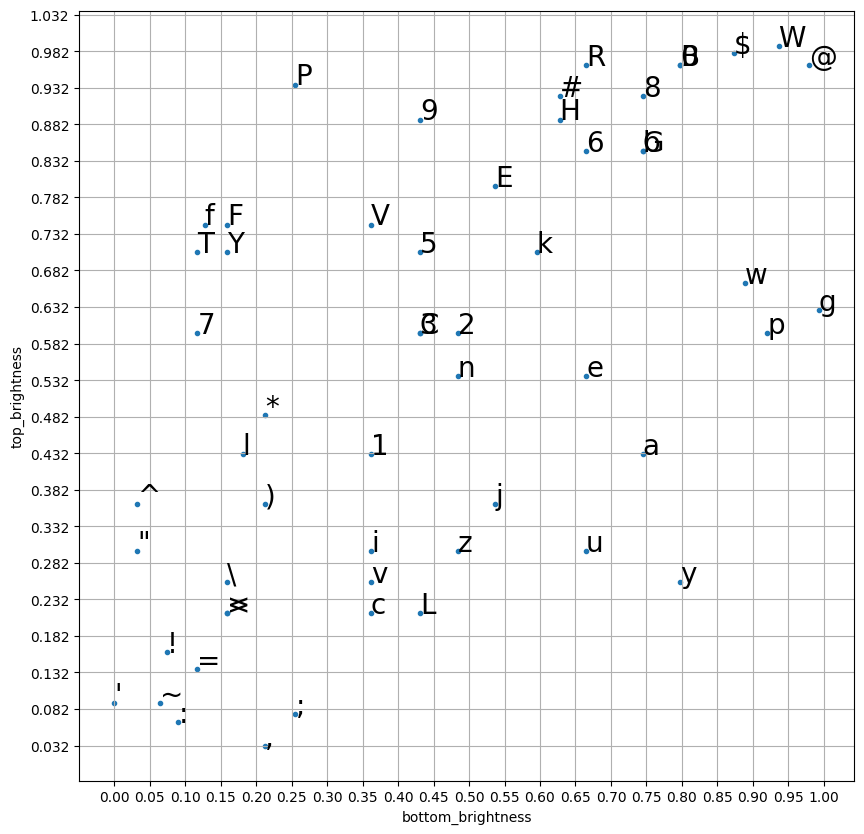

In [8]:
palette_chars = np.unique(palette)

s2b = {s: symbol2brightness[s] for s in palette_chars}
brightness = s2b.values()
top_brightness = [b[0][0] for b in brightness]
bottom_brightness = [b[1][0] for b in brightness]
plt.figure(figsize=(10, 10))
plt.scatter(bottom_brightness, top_brightness, marker='.')
plt.xticks(np.arange(min(bottom_brightness), max(bottom_brightness) + 0.05, 0.05))
plt.yticks(np.arange(min(top_brightness), max(top_brightness) + 0.05, 0.05))
plt.xlabel("bottom_brightness")
plt.ylabel("top_brightness")
for row in range(len(palette_chars)):
    plt.annotate(palette_chars[row], (bottom_brightness[row], top_brightness[row]), size=20)
plt.grid()

d:\CS Projects\python-playground\python-ascii-art\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 127 () missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\CS Projects\python-playground\python-ascii-art\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


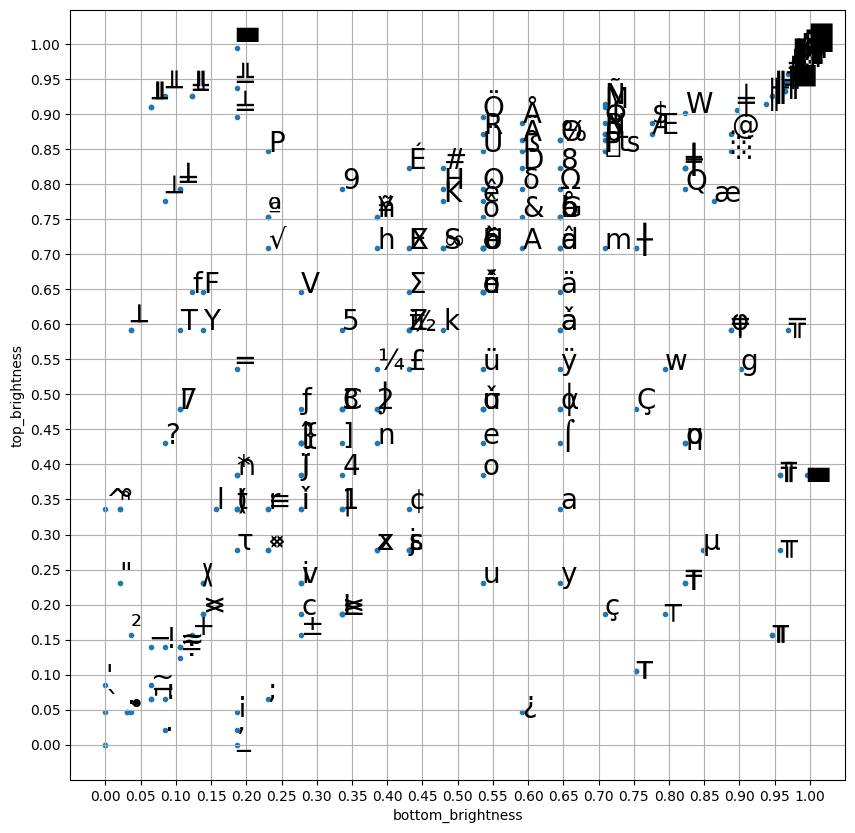

In [9]:
EXTENDED_SYMBOLS = PALETTES['extended_asciis']
symbol2brightness = make_symbol2value_map(
    symbols=EXTENDED_SYMBOLS,
    font=FONT,
    val_height=2,
    val_width=1,
    normalize=True)

brightness = list(symbol2brightness.values())
top_brightness = [b[0][0] for b in brightness]
bottom_brightness = [b[1][0] for b in brightness]

plt.figure(figsize=(10, 10))
plt.scatter(bottom_brightness, top_brightness, marker='.')
plt.xticks(np.arange(0.0, max(bottom_brightness) + 0.05, 0.05))
plt.yticks(np.arange(0.0, max(top_brightness) + 0.05, 0.05))
plt.xlabel("bottom_brightness")
plt.ylabel("top_brightness")
for s, btm_br, top_br in zip(EXTENDED_SYMBOLS, bottom_brightness, top_brightness):
    plt.annotate(s, (btm_br, top_br), size=20)
plt.grid()